In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.io import loadmat

In [3]:
dataset_path = Path("../dataset")

splits_path = dataset_path / "splits"

raw_data_path = dataset_path / "raw_data"

print("Dataset path:", dataset_path)
print("Splits path:", splits_path)

print("\nRaw Data path:", raw_data_path)

Dataset path: ..\dataset
Splits path: ..\dataset\splits

Raw Data path: ..\dataset\raw_data


In [4]:
train_df = pd.read_csv(splits_path / "train.csv")
validation_df = pd.read_csv(splits_path / "validation.csv")
test_df = pd.read_csv(splits_path / "test.csv")

print("===== DATASET SIZES =====")

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

===== DATASET SIZES =====
Train: 5969
Validation: 1279
Test: 1280


In [5]:
print("===== TRAIN =====")
print(train_df["label"].value_counts())

print("\n===== VALIDATION =====")
print(validation_df["label"].value_counts())

print("\n===== TEST =====")
print(test_df["label"].value_counts())

===== TRAIN =====
label
N    3553
O    1690
A     531
~     195
Name: count, dtype: int64

===== VALIDATION =====
label
N    761
O    362
A    114
~     42
Name: count, dtype: int64

===== TEST =====
label
N    762
O    363
A    113
~     42
Name: count, dtype: int64


In [6]:
TARGET_LENGTH = 9000
SAMPLING_RATE = 300

print("Target length:", TARGET_LENGTH)
print("Sampling rate:", SAMPLING_RATE)
print("Target duration:", TARGET_LENGTH / SAMPLING_RATE, "seconds")

Target length: 9000
Sampling rate: 300
Target duration: 30.0 seconds


In [7]:
def preprocess_ecg(ecg, target_length=TARGET_LENGTH):
    """
    Convert an ECG signal to a fixed length.

    Shorter signals -> zero padding
    Longer signals  -> truncation
    Exact length    -> unchanged
    """

    ecg = np.asarray(ecg).flatten()

    current_length = len(ecg)

    if current_length < target_length:
        # Zero padding
        ecg = np.pad(
            ecg,
            (0, target_length - current_length),
            mode="constant"
        )

    elif current_length > target_length:
        # Truncation
        ecg = ecg[:target_length]

    return ecg

In [8]:
def get_ecg_path(record):
    """
    Convert a record ID such as:
        A03/A03779

    into the corresponding MAT file path.
    """

    return raw_data_path / f"{record}.mat"

In [9]:
test_record = train_df.iloc[0]["record"]

test_path = get_ecg_path(test_record)

print("Record:")
print(test_record)

print("\nMAT path:")
print(test_path)

print("\nExists:")
print(test_path.exists())

Record:
A03/A03779

MAT path:
..\dataset\raw_data\A03\A03779.mat

Exists:
True


In [10]:
data = loadmat(test_path)

print(data.keys())

dict_keys(['val'])


In [11]:
data = loadmat(test_path)

ecg = data["val"]

print("Original shape:", ecg.shape)

ecg = ecg.flatten()

print("Flattened shape:", ecg.shape)
print("Number of samples:", len(ecg))

Original shape: (1, 9000)
Flattened shape: (9000,)
Number of samples: 9000


In [12]:
processed_ecg = preprocess_ecg(ecg)

print("Original length:", len(ecg))
print("Processed length:", len(processed_ecg))

Original length: 9000
Processed length: 9000


In [13]:
def create_dataset(df):
    """
    Load ECG signals corresponding to records in a CSV,
    preprocess them to a fixed length, and return X and y.
    """

    X = []
    y = []

    for i, row in df.iterrows():

        record = row["record"]
        label = row["label"]

        # Path to MAT file
        mat_path = get_ecg_path(record)

        # Check file exists
        if not mat_path.exists():
            print(f"Warning: file not found -> {mat_path}")
            continue

        # Load MAT
        data = loadmat(mat_path)

        # Extract ECG
        ecg = data["val"].flatten()

        # Preprocess
        ecg = preprocess_ecg(ecg)

        X.append(ecg)
        y.append(label)

        # Progress
        if (i + 1) % 500 == 0:
            print(f"{i + 1} records processed")

    X = np.array(X)
    y = np.array(y)

    return X, y

In [14]:
X_train, y_train = create_dataset(train_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

500 records processed
1000 records processed
1500 records processed
2000 records processed
2500 records processed
3000 records processed
3500 records processed
4000 records processed
4500 records processed
5000 records processed
5500 records processed
X_train shape: (5969, 9000)
y_train shape: (5969,)


In [15]:
X_validation, y_validation = create_dataset(
    validation_df,
)

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

500 records processed
1000 records processed
X_validation shape: (1279, 9000)
y_validation shape: (1279,)


In [16]:
X_test, y_test = create_dataset(
    test_df,
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

500 records processed
1000 records processed
X_test shape: (1280, 9000)
y_test shape: (1280,)


In [17]:
print("X_train dtype:", X_train.dtype)

print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())
print("Mean value:", X_train.mean())
print("Standard deviation:", X_train.std())

X_train dtype: int16
Minimum value: -10636
Maximum value: 8318
Mean value: 7.0518668118612835
Standard deviation: 235.1425513461096


In [18]:
print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_validation))
print("Unique test labels:", np.unique(y_test))

Unique training labels: ['A' 'N' 'O' '~']
Unique validation labels: ['A' 'N' 'O' '~']
Unique test labels: ['A' 'N' 'O' '~']


In [19]:
label_mapping = {
    "N": 0,
    "A": 1,
    "O": 2,
    "~": 3
}

y_train_encoded = np.array([
    label_mapping[label] for label in y_train
])

y_validation_encoded = np.array([
    label_mapping[label] for label in y_validation
])

y_test_encoded = np.array([
    label_mapping[label] for label in y_test
])

In [20]:
print("Original labels:")
print(np.unique(y_train))

print("\nEncoded labels:")
print(np.unique(y_train_encoded))

print("\nFirst 20 original labels:")
print(y_train[:20])

print("\nFirst 20 encoded labels:")
print(y_train_encoded[:20])

Original labels:
['A' 'N' 'O' '~']

Encoded labels:
[0 1 2 3]

First 20 original labels:
['N' 'O' 'O' 'N' 'A' 'N' 'N' 'N' 'A' 'A' 'N' 'N' 'N' 'A' 'A' 'O' 'N' 'A'
 'N' 'N']

First 20 encoded labels:
[0 2 2 0 1 0 0 0 1 1 0 0 0 1 1 2 0 1 0 0]


In [21]:
X_train_cnn = X_train[..., np.newaxis]
X_validation_cnn = X_validation[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

In [22]:
print("===== CNN INPUT SHAPES =====")

print("X_train:", X_train_cnn.shape)
print("X_validation:", X_validation_cnn.shape)
print("X_test:", X_test_cnn.shape)

print("\n===== LABEL SHAPES =====")

print("y_train:", y_train_encoded.shape)
print("y_validation:", y_validation_encoded.shape)
print("y_test:", y_test_encoded.shape)

===== CNN INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)

===== LABEL SHAPES =====
y_train: (5969,)
y_validation: (1279,)
y_test: (1280,)


In [23]:
print("===== NaN / Inf CHECK =====")

print("X_train NaN:", np.isnan(X_train).sum())
print("X_train Inf:", np.isinf(X_train).sum())

print("X_validation NaN:", np.isnan(X_validation).sum())
print("X_validation Inf:", np.isinf(X_validation).sum())

print("X_test NaN:", np.isnan(X_test).sum())
print("X_test Inf:", np.isinf(X_test).sum())

===== NaN / Inf CHECK =====
X_train NaN: 0
X_train Inf: 0
X_validation NaN: 0
X_validation Inf: 0
X_test NaN: 0
X_test Inf: 0


In [24]:
print("===== SIGNAL LENGTH CHECK =====")

print("Train lengths:", X_train.shape[1])
print("Validation lengths:", X_validation.shape[1])
print("Test lengths:", X_test.shape[1])

===== SIGNAL LENGTH CHECK =====
Train lengths: 9000
Validation lengths: 9000
Test lengths: 9000


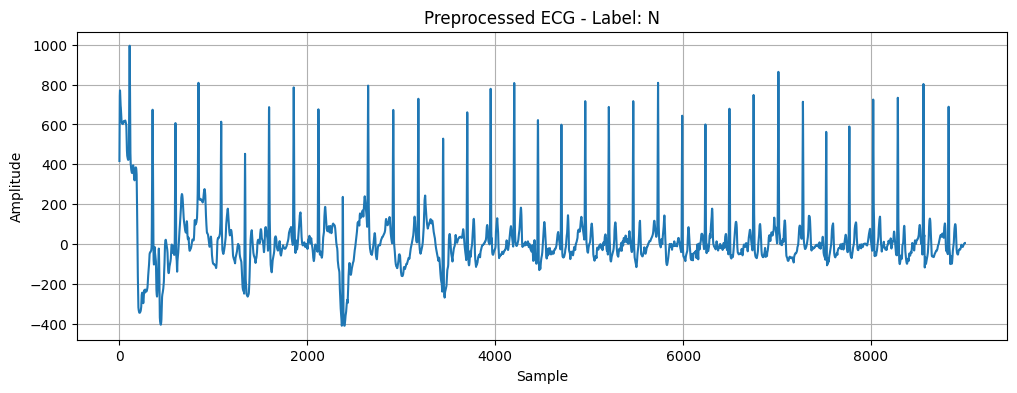

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(X_train[0])

plt.title(f"Preprocessed ECG - Label: {y_train[0]}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.grid()
plt.show()

In [26]:
dl_data_path = dataset_path / "dl_data"

dl_data_path.mkdir(exist_ok=True)

print("DL data path:")
print(dl_data_path)

DL data path:
..\dataset\dl_data


In [27]:
np.save(dl_data_path / "X_train.npy", X_train)
np.save(dl_data_path / "X_validation.npy", X_validation)
np.save(dl_data_path / "X_test.npy", X_test)

print("X datasets saved successfully.")

X datasets saved successfully.


In [28]:
np.save(dl_data_path / "y_train.npy", y_train_encoded)
np.save(dl_data_path / "y_validation.npy", y_validation_encoded)
np.save(dl_data_path / "y_test.npy", y_test_encoded)

print("Y datasets saved successfully.")

Y datasets saved successfully.


In [29]:
print("===== SAVED FILES =====")

for file in sorted(dl_data_path.glob("*.npy")):
    print(file.name, "->", round(file.stat().st_size / (1024 ** 2), 2), "MB")

===== SAVED FILES =====
X_test.npy -> 21.97 MB
X_train.npy -> 102.46 MB
X_validation.npy -> 21.96 MB
y_test.npy -> 0.01 MB
y_train.npy -> 0.02 MB
y_validation.npy -> 0.01 MB
